In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt

In [84]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.features.build_features import split_and_encode

In [85]:
df = pd.read_csv("../data/processed/flights_sample_3m_cleaned.csv")

In [86]:
print(df.shape)
df.head()

(2913802, 11)


,FL_DATE,AIRLINE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,is_delayed
0,2019-01-09,United Air Lines Inc.,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1501,186.0,1065.0,0
1,2022-11-19,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2315,235.0,1399.0,0
2,2022-07-22,United Air Lines Inc.,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1252,118.0,680.0,0
3,2023-03-06,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1829,260.0,1589.0,0
4,2020-02-23,Spirit Air Lines,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,2041,181.0,985.0,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2913802 entries, 0 to 2913801
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   FL_DATE           object 
 1   AIRLINE           object 
 2   ORIGIN            object 
 3   ORIGIN_CITY       object 
 4   DEST              object 
 5   DEST_CITY         object 
 6   CRS_DEP_TIME      int64  
 7   CRS_ARR_TIME      int64  
 8   CRS_ELAPSED_TIME  float64
 9   DISTANCE          float64
 10  is_delayed        int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 244.5+ MB


1. convertint FL_DATE to actual datetime instread of string

In [88]:
df['FL_DATE']=pd.to_datetime(df['FL_DATE'])

In [89]:
df.dtypes

FL_DATE             datetime64[ns]
AIRLINE                     object
ORIGIN                      object
ORIGIN_CITY                 object
DEST                        object
DEST_CITY                   object
CRS_DEP_TIME                 int64
CRS_ARR_TIME                 int64
CRS_ELAPSED_TIME           float64
DISTANCE                   float64
is_delayed                   int64
dtype: object

2. Doing Some feature engineering to this data and ctreating some new column

In [90]:
df['SCHED_HOUR']=df['CRS_DEP_TIME']//100

df['MONTH'] =df['FL_DATE'].dt.month

df['DAY_OF_WEEK'] = df['FL_DATE'].dt.day_of_week

df['DAYS_MONTH']= df['FL_DATE'].dt.day

df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5,6]).astype(int)

In [91]:
df.head()

,FL_DATE,AIRLINE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,is_delayed,SCHED_HOUR,MONTH,DAY_OF_WEEK,DAYS_MONTH,IS_WEEKEND
0,2019-01-09,United Air Lines Inc.,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1501,186.0,1065.0,0,11,1,2,9,0
1,2022-11-19,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2315,235.0,1399.0,0,21,11,5,19,1
2,2022-07-22,United Air Lines Inc.,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1252,118.0,680.0,0,9,7,4,22,0
3,2023-03-06,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1829,260.0,1589.0,0,16,3,0,6,0
4,2020-02-23,Spirit Air Lines,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,2041,181.0,985.0,0,18,2,6,23,1


3. cyclical Encoding

In [92]:
# OF HOURS
df['HOUR_SIN']=np.sin(2*np.pi*df['SCHED_HOUR']/24)
df['HOUR_COS']=np.cos(2*np.pi*df['SCHED_HOUR']/24)

# OF DAYS OF WEEK
df['DOW_SIN'] = np.sin(2*np.pi*df['DAY_OF_WEEK']/7)
df['DOW_COS'] = np.cos(2*np.pi*df['DAY_OF_WEEK']/7)

# OF DAYS OF MONTH
df['MONTH_SIN'] = np.sin(2*np.pi*df['MONTH']/12)
df['MONTH_COS'] = np.cos(2*np.pi*df['MONTH']/12)


In [93]:
df.head()

,FL_DATE,AIRLINE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,...,MONTH,DAY_OF_WEEK,DAYS_MONTH,IS_WEEKEND,HOUR_SIN,HOUR_COS,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS
0,2019-01-09,United Air Lines Inc.,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1501,186.0,1065.0,...,1,2,9,0,0.258819,-9.659258e-01,0.974928,-0.222521,0.500000,8.660254e-01
1,2022-11-19,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2315,235.0,1399.0,...,11,5,19,1,-0.707107,7.071068e-01,-0.974928,-0.222521,-0.500000,8.660254e-01
2,2022-07-22,United Air Lines Inc.,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1252,118.0,680.0,...,7,4,22,0,0.707107,-7.071068e-01,-0.433884,-0.900969,-0.500000,-8.660254e-01
3,2023-03-06,Delta Air Lines Inc.,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1829,260.0,1589.0,...,3,0,6,0,-0.866025,-5.000000e-01,0.000000,1.000000,1.000000,6.123234e-17
4,2020-02-23,Spirit Air Lines,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,2041,181.0,985.0,...,2,6,23,1,-1.000000,-1.836970e-16,-0.781831,0.623490,0.866025,5.000000e-01


4. ADD A ROUTE FEATURE by combining origin and destination

In [94]:
df['ROUTE']=(df['ORIGIN']+ "_" + df['DEST'])

In [95]:
df['ROUTE']

0          FLL_EWR
1          MSP_SEA
2          DEN_MSP
3          MSP_SFO
4          MCO_DFW
            ...   
2913797    JAX_CLT
2913798    ORD_AUS
2913799    HSV_ATL
2913800    BOS_LGA
2913801    LGB_SJC
Name: ROUTE, Length: 2913802, dtype: object

<Axes: xlabel='DISTANCE', ylabel='Count'>

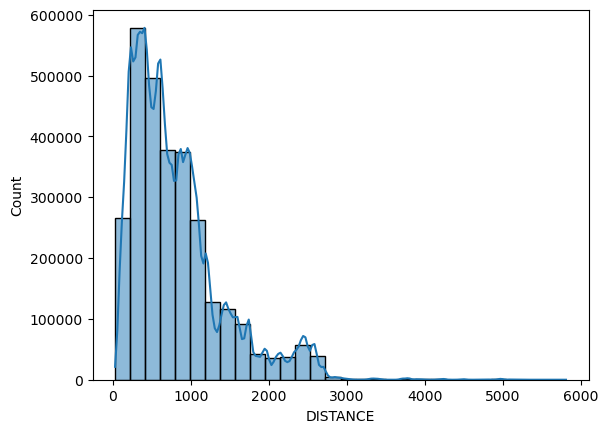

In [96]:
df['DISTANCE'].agg(['mean', 'max', 'min'])
sns.histplot(data=df, x='DISTANCE', kde=True, bins=30)

In [97]:
df["distance_bucket"] = pd.cut(
    df["DISTANCE"],
    bins=[0, 500, 1000, 2000, np.inf],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

<Axes: xlabel='distance_bucket', ylabel='Count'>

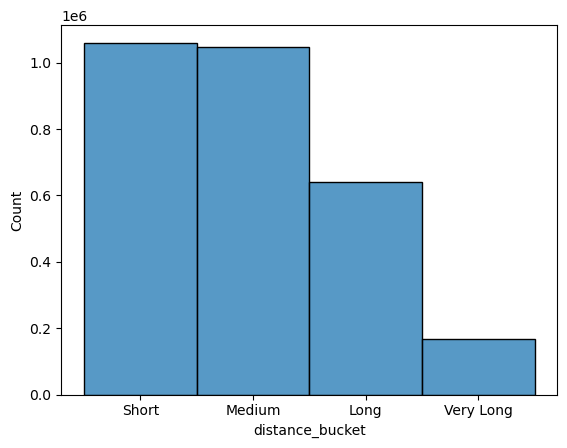

In [98]:
sns.histplot(df, x='distance_bucket')

##  SPLITING THE DATA
* spliting in a way so that the test got past data 19-22 and test got 22-23 data , such we can actully simulate future

In [209]:
df = (
    df
    .sort_values("FL_DATE")
    .reset_index(drop=True)
)

In [232]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()

test_df = df.iloc[split_index:].copy()

In [233]:
train_df.head()

,FL_DATE,AIRLINE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,...,DAYS_MONTH,IS_WEEKEND,HOUR_SIN,HOUR_COS,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,ROUTE,distance_bucket
0,2019-01-01,Southwest Airlines Co.,RIC,"Richmond, VA",ATL,"Atlanta, GA",1715,1900,105.0,481.0,...,1,0,-0.965926,-0.258819,0.781831,0.62349,0.5,0.866025,RIC_ATL,Short
1,2019-01-01,American Airlines Inc.,DEN,"Denver, CO",DFW,"Dallas/Fort Worth, TX",1440,1739,119.0,641.0,...,1,0,-0.500000,-0.866025,0.781831,0.62349,0.5,0.866025,DEN_DFW,Medium
2,2019-01-01,Delta Air Lines Inc.,TPA,"Tampa, FL",ATL,"Atlanta, GA",949,1120,91.0,406.0,...,1,0,0.707107,-0.707107,0.781831,0.62349,0.5,0.866025,TPA_ATL,Short
3,2019-01-01,SkyWest Airlines Inc.,SDF,"Louisville, KY",ORD,"Chicago, IL",813,859,106.0,286.0,...,1,0,0.866025,-0.500000,0.781831,0.62349,0.5,0.866025,SDF_ORD,Short
4,2019-01-01,Envoy Air,MSO,"Missoula, MT",DFW,"Dallas/Fort Worth, TX",1337,1802,205.0,1320.0,...,1,0,-0.258819,-0.965926,0.781831,0.62349,0.5,0.866025,MSO_DFW,Long


### Adding delay rates to the data

In [234]:
TARGET = "is_delayed"

global_mean = train_df[TARGET].mean()

In [235]:
def add_historical_rate(
    train_df,
    test_df,
    column,
    target="is_delayed"
):
    """
    Create leakage-safe historical rate features.
    """

    rate_map = train_df.groupby(column)[target].mean()

    train_df[f"{column.lower()}_delay_rate"] = (
        train_df[column].map(rate_map)
    )

    test_df[f"{column.lower()}_delay_rate"] = (
        test_df[column]
        .map(rate_map)
        .fillna(global_mean)
    )

    return train_df, test_df

Airline 

In [236]:
train_df, test_df = add_historical_rate(
    train_df,
    test_df,
    "AIRLINE"
)

origin

In [237]:
train_df, test_df = add_historical_rate(
    train_df,
    test_df,
    "ORIGIN"
)

Destination

In [238]:
train_df, test_df = add_historical_rate(
    train_df,
    test_df,
    "DEST"
)

route

In [239]:
train_df, test_df = add_historical_rate(
    train_df,
    test_df,
    "ROUTE"
)

In [240]:
print(train_df["FL_DATE"].min())
print(train_df["FL_DATE"].max())

print(test_df["FL_DATE"].min())
print(test_df["FL_DATE"].max())

2019-01-01 00:00:00
2022-10-21 00:00:00
2022-10-21 00:00:00
2023-08-31 00:00:00


<Axes: xlabel='FL_DATE'>

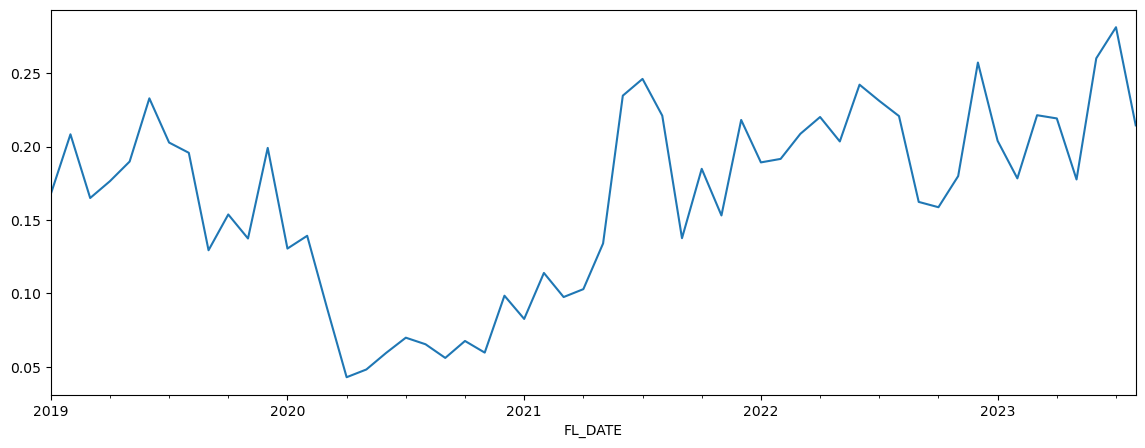

In [241]:
(
    df
    .groupby(df["FL_DATE"].dt.to_period("M"))["is_delayed"]
    .mean()
    .plot(figsize=(14,5))
)

check the class balance of the data 

In [242]:
print(train_df["is_delayed"].value_counts(normalize=True))

print(test_df["is_delayed"].value_counts(normalize=True))

is_delayed
0    0.835445
1    0.164555
Name: proportion, dtype: float64
is_delayed
0    0.781796
1    0.218204
Name: proportion, dtype: float64


## PREPROCESSING AND ENCODING

1. droping some columns

In [243]:
drop_cols=['FL_DATE',
    

    'SCHED_HOUR',
    'DAY_OF_WEEK',
    'MONTH',
    'DAYS_MONTH',

    "ORIGIN_CITY",
    "DEST_CITY",

    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    ]

train_df= train_df.drop(columns=drop_cols)

2. target and feature seperation

In [244]:
TARGET = "is_delayed"

X_train = train_df.drop(columns=[TARGET])
X_test = test_df.drop(columns=[TARGET])

y_train = train_df[TARGET]
y_test = test_df[TARGET]

In [245]:
X_train.columns.to_list()

['AIRLINE',
 'ORIGIN',
 'DEST',
 'CRS_ELAPSED_TIME',
 'DISTANCE',
 'IS_WEEKEND',
 'HOUR_SIN',
 'HOUR_COS',
 'DOW_SIN',
 'DOW_COS',
 'MONTH_SIN',
 'MONTH_COS',
 'ROUTE',
 'distance_bucket',
 'airline_delay_rate',
 'origin_delay_rate',
 'dest_delay_rate',
 'route_delay_rate']

In [246]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2331041 entries, 0 to 2331040
Data columns (total 18 columns):
 #   Column              Dtype   
---  ------              -----   
 0   AIRLINE             object  
 1   ORIGIN              object  
 2   DEST                object  
 3   CRS_ELAPSED_TIME    float64 
 4   DISTANCE            float64 
 5   IS_WEEKEND          int64   
 6   HOUR_SIN            float64 
 7   HOUR_COS            float64 
 8   DOW_SIN             float64 
 9   DOW_COS             float64 
 10  MONTH_SIN           float64 
 11  MONTH_COS           float64 
 12  ROUTE               object  
 13  distance_bucket     category
 14  airline_delay_rate  float64 
 15  origin_delay_rate   float64 
 16  dest_delay_rate     float64 
 17  route_delay_rate    float64 
dtypes: category(1), float64(12), int64(1), object(4)
memory usage: 304.6+ MB


In [247]:
X_train.head()

,AIRLINE,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,IS_WEEKEND,HOUR_SIN,HOUR_COS,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,ROUTE,distance_bucket,airline_delay_rate,origin_delay_rate,dest_delay_rate,route_delay_rate
0,Southwest Airlines Co.,RIC,ATL,105.0,481.0,0,-0.965926,-0.258819,0.781831,0.62349,0.5,0.866025,RIC_ATL,Short,0.207489,0.148743,0.123397,0.082915
1,American Airlines Inc.,DEN,DFW,119.0,641.0,0,-0.500000,-0.866025,0.781831,0.62349,0.5,0.866025,DEN_DFW,Medium,0.173540,0.210663,0.162134,0.179283
2,Delta Air Lines Inc.,TPA,ATL,91.0,406.0,0,0.707107,-0.707107,0.781831,0.62349,0.5,0.866025,TPA_ATL,Short,0.125391,0.166259,0.123397,0.123707
3,SkyWest Airlines Inc.,SDF,ORD,106.0,286.0,0,0.866025,-0.500000,0.781831,0.62349,0.5,0.866025,SDF_ORD,Short,0.139879,0.145914,0.161461,0.151815
4,Envoy Air,MSO,DFW,205.0,1320.0,0,-0.258819,-0.965926,0.781831,0.62349,0.5,0.866025,MSO_DFW,Long,0.138465,0.139264,0.162134,0.165775


In [248]:
categorical_features = [
    "distance_bucket",
    "AIRLINE",
    "ORIGIN",
    "DEST",
]

numerical_features = [
    "DISTANCE",
    "CRS_ELAPSED_TIME",

    "IS_WEEKEND",

    "HOUR_SIN",
    "HOUR_COS",

    "DOW_SIN",
    "DOW_COS",

    "MONTH_SIN",
    "MONTH_COS",
]

3. Build Preprocessing Pipeline

In [249]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [266]:
numeric_pipeline=make_pipeline(
    SimpleImputer(strategy='median'),
)


categorical_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore'),
)

In [267]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features),
        ('cat',categorical_pipeline, categorical_features),
    ]
)

In [268]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [269]:
print(X_train_processed.shape)
print(X_test_processed.shape)

feature_names = preprocessor.get_feature_names_out()

print(feature_names)

(2331041, 791)
(582761, 791)
['num__DISTANCE' 'num__CRS_ELAPSED_TIME' 'num__IS_WEEKEND' 'num__HOUR_SIN'
 'num__HOUR_COS' 'num__DOW_SIN' 'num__DOW_COS' 'num__MONTH_SIN'
 'num__MONTH_COS' 'cat__distance_bucket_Long'
 'cat__distance_bucket_Medium' 'cat__distance_bucket_Short'
 'cat__distance_bucket_Very Long' 'cat__AIRLINE_Alaska Airlines Inc.'
 'cat__AIRLINE_Allegiant Air' 'cat__AIRLINE_American Airlines Inc.'
 'cat__AIRLINE_Delta Air Lines Inc.' 'cat__AIRLINE_Endeavor Air Inc.'
 'cat__AIRLINE_Envoy Air'
 'cat__AIRLINE_ExpressJet Airlines LLC d/b/a aha!'
 'cat__AIRLINE_Frontier Airlines Inc.'
 'cat__AIRLINE_Hawaiian Airlines Inc.' 'cat__AIRLINE_Horizon Air'
 'cat__AIRLINE_JetBlue Airways' 'cat__AIRLINE_Mesa Airlines Inc.'
 'cat__AIRLINE_PSA Airlines Inc.' 'cat__AIRLINE_Republic Airline'
 'cat__AIRLINE_SkyWest Airlines Inc.'
 'cat__AIRLINE_Southwest Airlines Co.' 'cat__AIRLINE_Spirit Air Lines'
 'cat__AIRLINE_United Air Lines Inc.' 'cat__ORIGIN_ABE' 'cat__ORIGIN_ABI'
 'cat__ORIGIN_ABQ' 'c

## BASELINE MODEL

In [254]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

In [255]:
model = LogisticRegression(
    penalty="l2",
    C=0.1,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)

model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [256]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

In [257]:
y_pred = (y_prob >= 0.5).astype(int)

In [258]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
}

for metric, value in metrics.items():
    print(f"{metric:<12}: {value:.4f}")

Accuracy    : 0.6032
Precision   : 0.3059
Recall      : 0.6452
F1 Score    : 0.4151
ROC-AUC     : 0.6608


1. model-1 Score
(without route, airline, origin, dest)
* Accuracy    : 0.5783
* Precision   : 0.2932
* Recall      : 0.6612
* F1 Score    : 0.4063
* ROC-AUC     : 0.6439


2. model-2 Score(with route, airline)
* Accuracy    : 0.6047
* Precision   : 0.3067
* Recall      : 0.6440
* F1 Score    : 0.4155
* ROC-AUC     : 0.6615




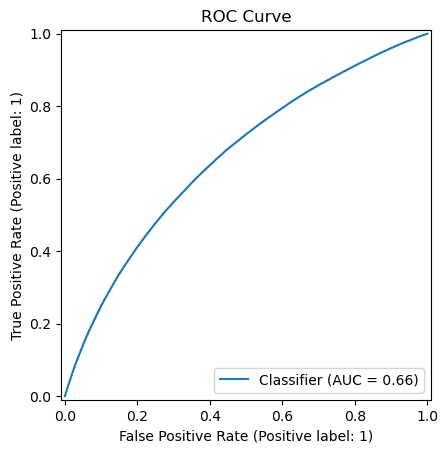

In [259]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
)

plt.title("ROC Curve")
plt.show()

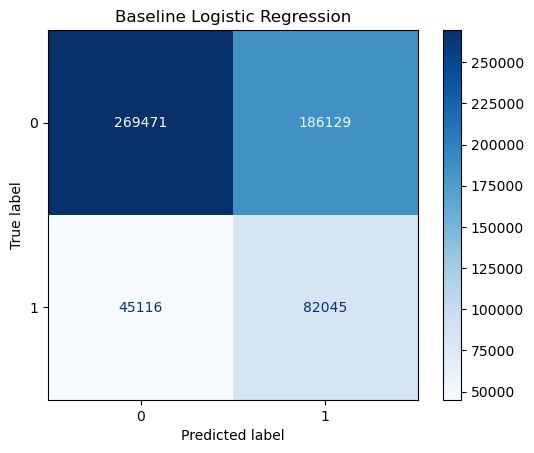

In [260]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
)

plt.title("Baseline Logistic Regression")
plt.show()

In [261]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Abs_Coefficient
83,cat__ORIGIN_BQN,0.759123,0.759123
463,cat__DEST_BQN,0.742845,0.742845
753,cat__DEST_SPS,-0.737196,0.737196
53,cat__ORIGIN_ASE,0.704341,0.704341
217,cat__ORIGIN_ITO,-0.653172,0.653172
379,cat__ORIGIN_STX,-0.594253,0.594253
534,cat__DEST_EWR,0.583730,0.583730
378,cat__ORIGIN_STT,-0.557913,0.557913
75,cat__ORIGIN_BLI,-0.535877,0.535877
621,cat__DEST_LGA,0.533496,0.533496


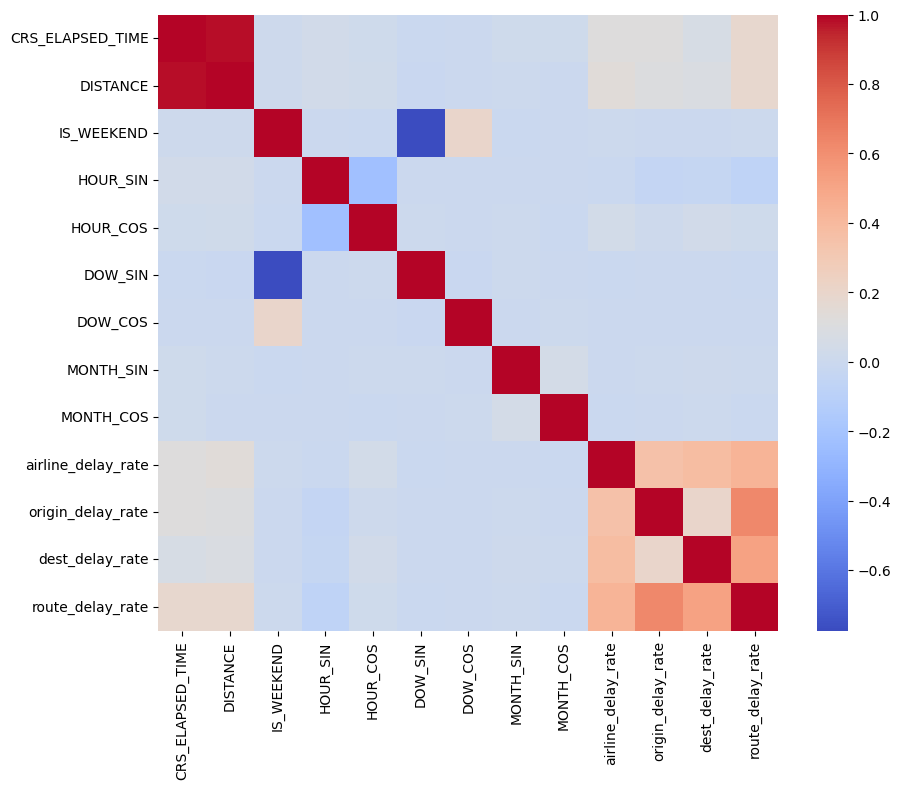

In [262]:
corr = X_train.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

## XGBoost

In [263]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [264]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(scale_pos_weight)

5.076986847765163


In [265]:
xgb = XGBClassifier(
    objective="binary:logistic",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=5,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0,

    reg_lambda=1,

    scale_pos_weight=scale_pos_weight,

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1
)

In [270]:
xgb.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [271]:
y_prob = xgb.predict_proba(X_test_processed)[:, 1]

y_pred = xgb.predict(X_test_processed)

In [274]:
xgb.score(X_train_processed, y_train)

0.6349849702343288

In [272]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
}

for metric, value in metrics.items():
    print(f"{metric:<12}: {value:.4f}")

Accuracy    : 0.6172
Precision   : 0.3154
Recall      : 0.6444
F1          : 0.4235
ROC-AUC     : 0.6772


In [273]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
3,num__HOUR_SIN,0.046570
28,cat__AIRLINE_Southwest Airlines Co.,0.038302
23,cat__AIRLINE_JetBlue Airways,0.033365
14,cat__AIRLINE_Allegiant Air,0.021068
154,cat__ORIGIN_EWR,0.018919
17,cat__AIRLINE_Endeavor Air Inc.,0.015641
16,cat__AIRLINE_Delta Air Lines Inc.,0.013831
4,num__HOUR_COS,0.013381
20,cat__AIRLINE_Frontier Airlines Inc.,0.012222
621,cat__DEST_LGA,0.012055
